In [1]:
%load_ext autoreload
%autoreload 2

import json

pattern = "pattern-1"

entrypoint = pattern
app_cwl_file = f"../cwl-workflow/{pattern}.cwl"

with open(f"../cwl-workflow/{pattern}-inputs.json", "r") as f:
    app_inputs = json.load(f)

try:
    from docs.helpers import plot_cwl, wrap_cwl
except (ImportError, ModuleNotFoundError) as e:

    import os
    import sys

    module_path = os.path.abspath(os.path.join("."))  # or the path to your source code
    sys.path.insert(0, module_path)

from helpers import WorkflowViewer, WorkflowWrapper, additional_inputs
from cwl_loader import dump_cwl
from pathlib import Path
from IPython.display import Markdown, display
import json

In [2]:
wf = WorkflowViewer.from_file(app_cwl_file, entrypoint)

## Application Package Pattern 

The CWL includes: 

- one input parameter of type `Directory`
- one output parameter of type `Directory`

This scenario typically takes one input, applies an algorithm and produces a result

Implementation: delineate water bodies using NDWI and Otsu automatic threshold taking as input a Landsat-8/9 acquisition

### Diagrams


#### State diagram

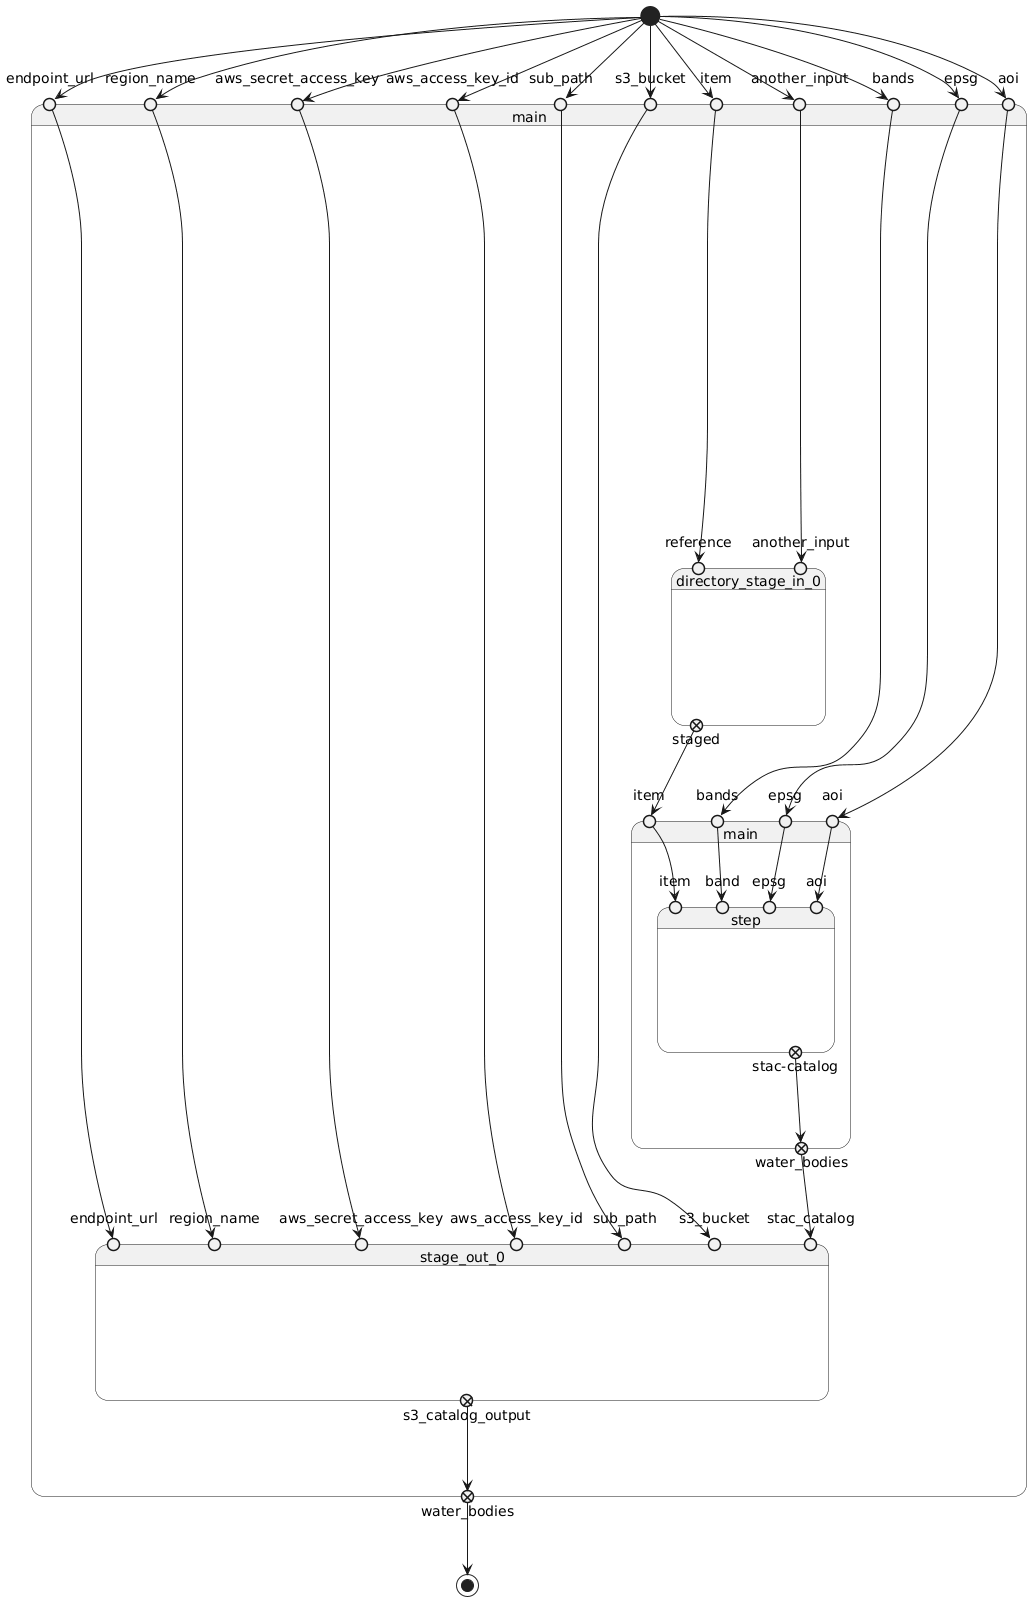

In [20]:
wf.display_state_diagram()

### Sequence diagram

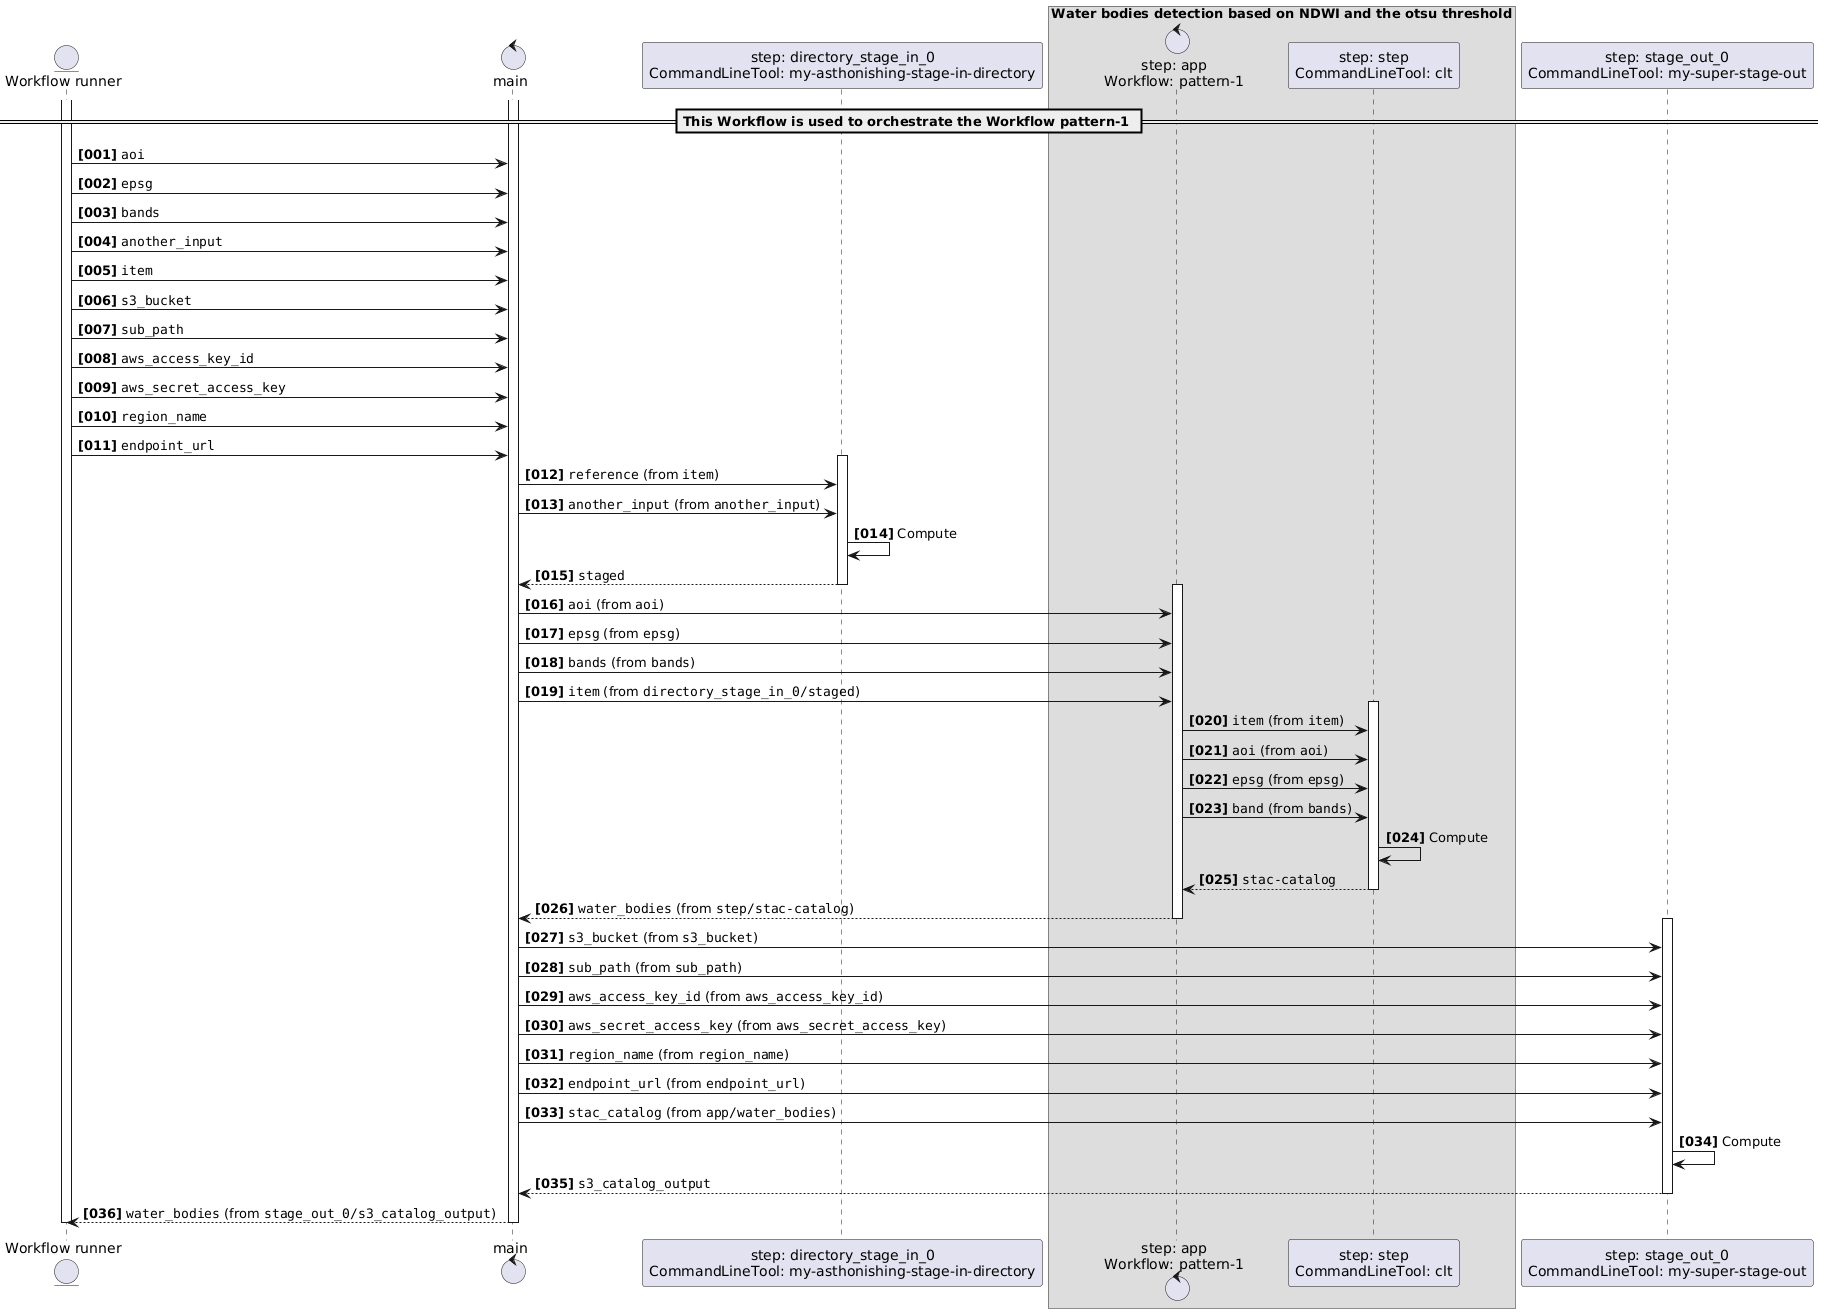

In [21]:
wf.display_sequence_diagram()

### Inputs

In [7]:
wf.display_inputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `aoi` | `string` | area of interest | area of interest as a bounding box |
| `epsg` | `string` | EPSG code | EPSG code |
| `bands` | `string[]` | bands used for the NDWI | bands used for the NDWI |
| `item` | `Directory` | Landsat-8/9 acquisition reference | Landsat-8/9 acquisition reference |


### Steps

In [8]:
wf.display_steps()

| Id | Runs | Label | Doc |
| --- | --- | --- | --- |
| `step` | `#clt` | Water bodies detection | Water bodies detection based on NDWI and otsu threshold applied to a single Landsat-8/9 acquisition |


### Outputs

In [9]:
wf.display_outputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `water_bodies` | `Directory` | Water bodies detected | Water bodies detected based on the NDWI and otsu threshold |


## Data flow management

In [ ]:
w = WorkflowWrapper(workflow=wf.workflow, entrypoint=entrypoint)
wrapped = w.wrap()

app_cwl_file = f".{entrypoint}.cwl"

with open(app_cwl_file, "w") as f:
    dump_cwl(process=wrapped, stream=f)

wf = WorkflowViewer(cwl_file=app_cwl_file, workflow=wrapped, entrypoint="main")

### State diagram


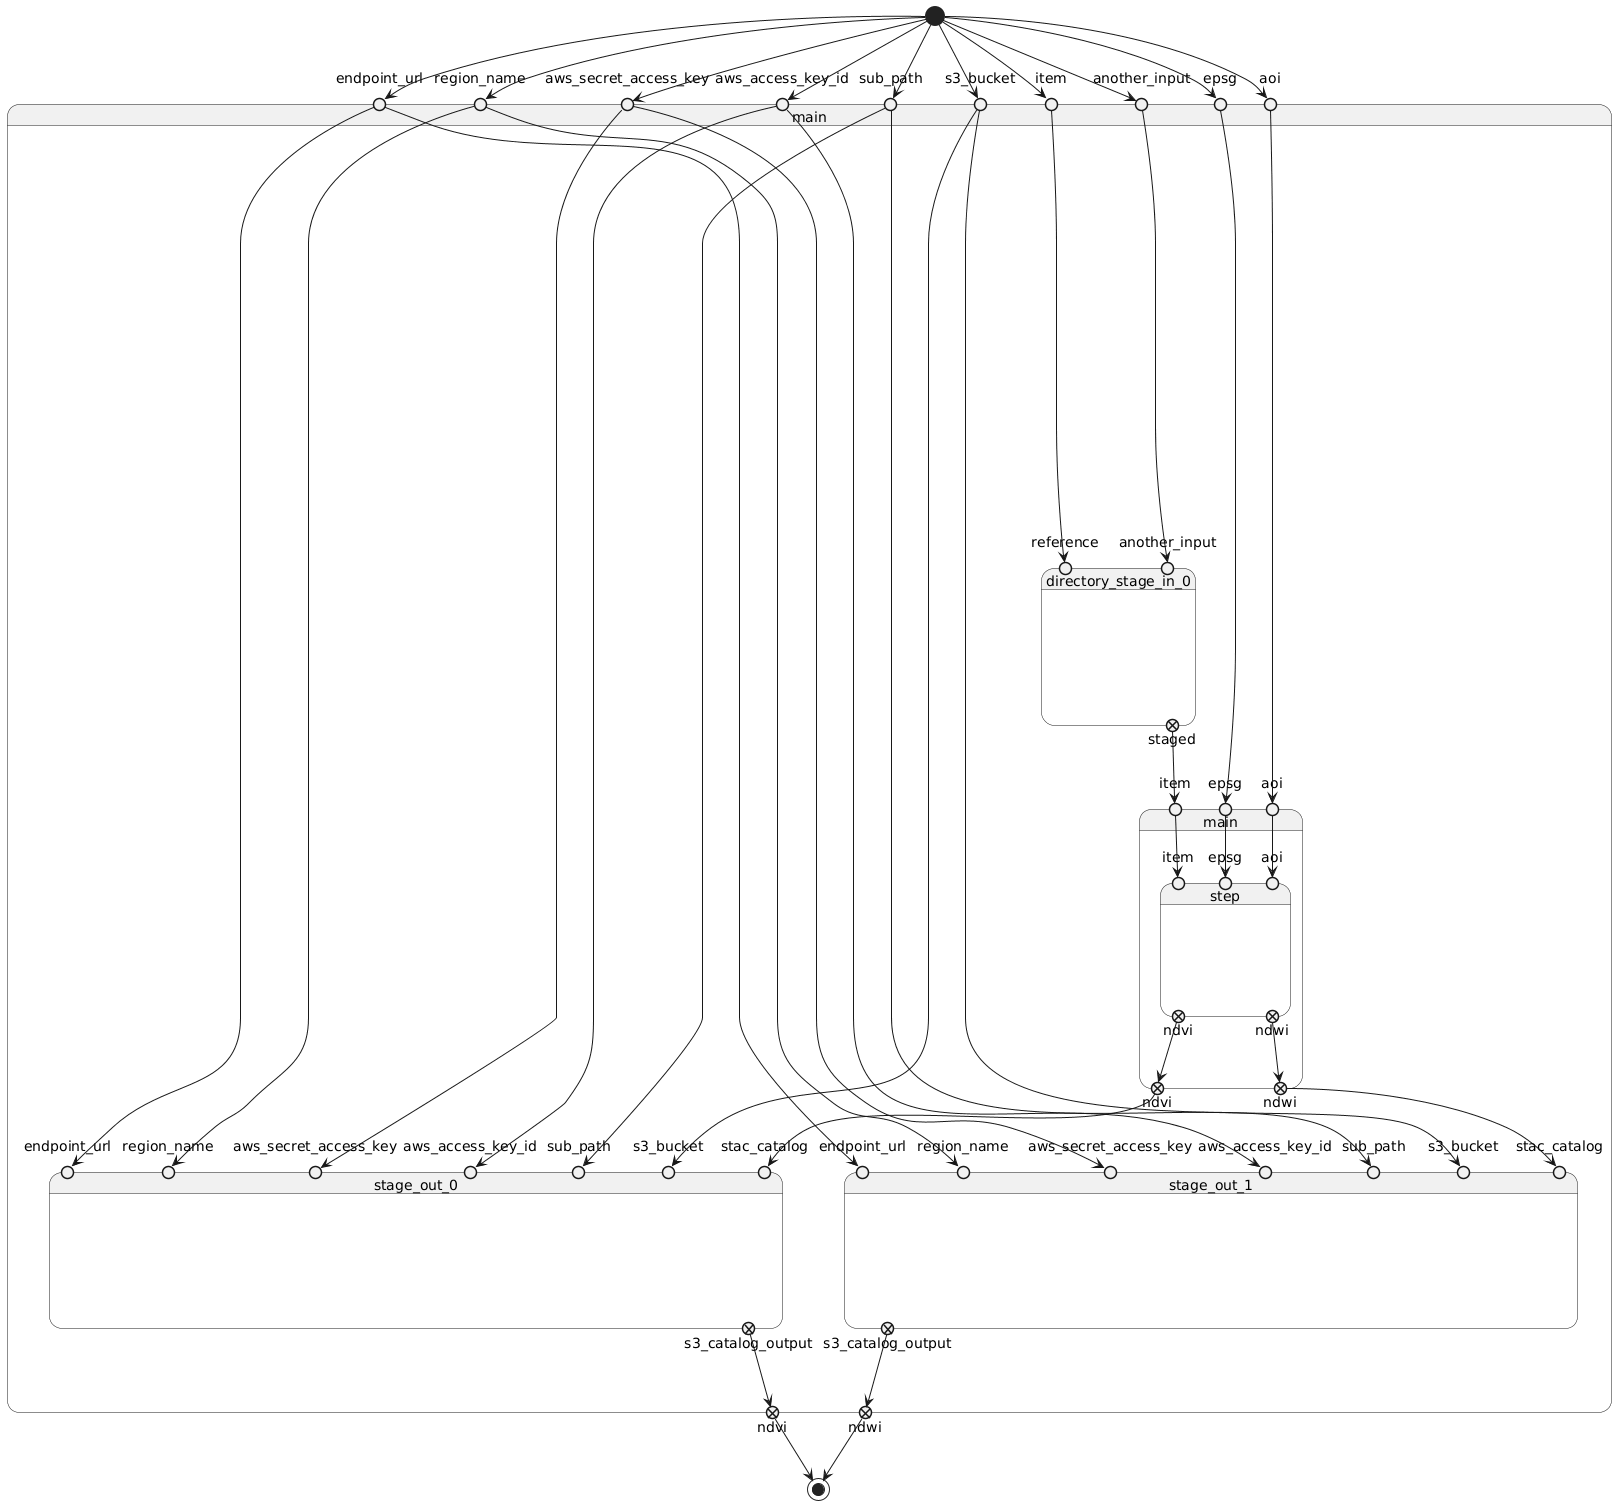

In [ ]:
wf.display_state_diagram()

### Sequence diagram

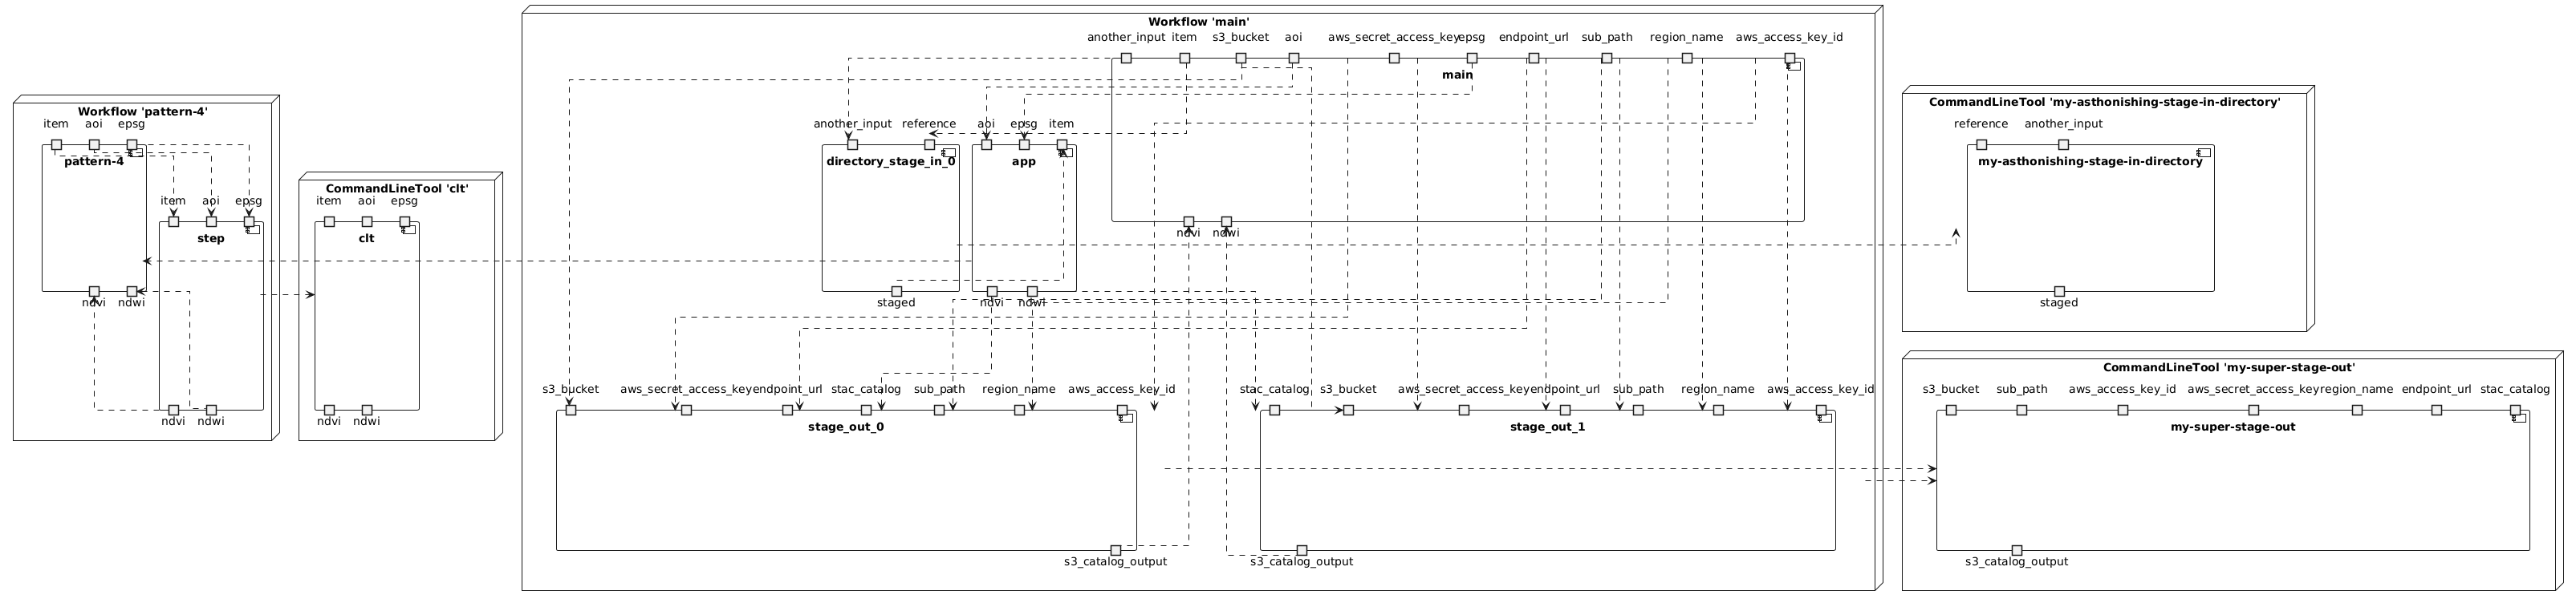

In [ ]:

wf.display_sequence_diagram()

### Workflow sequence diagram

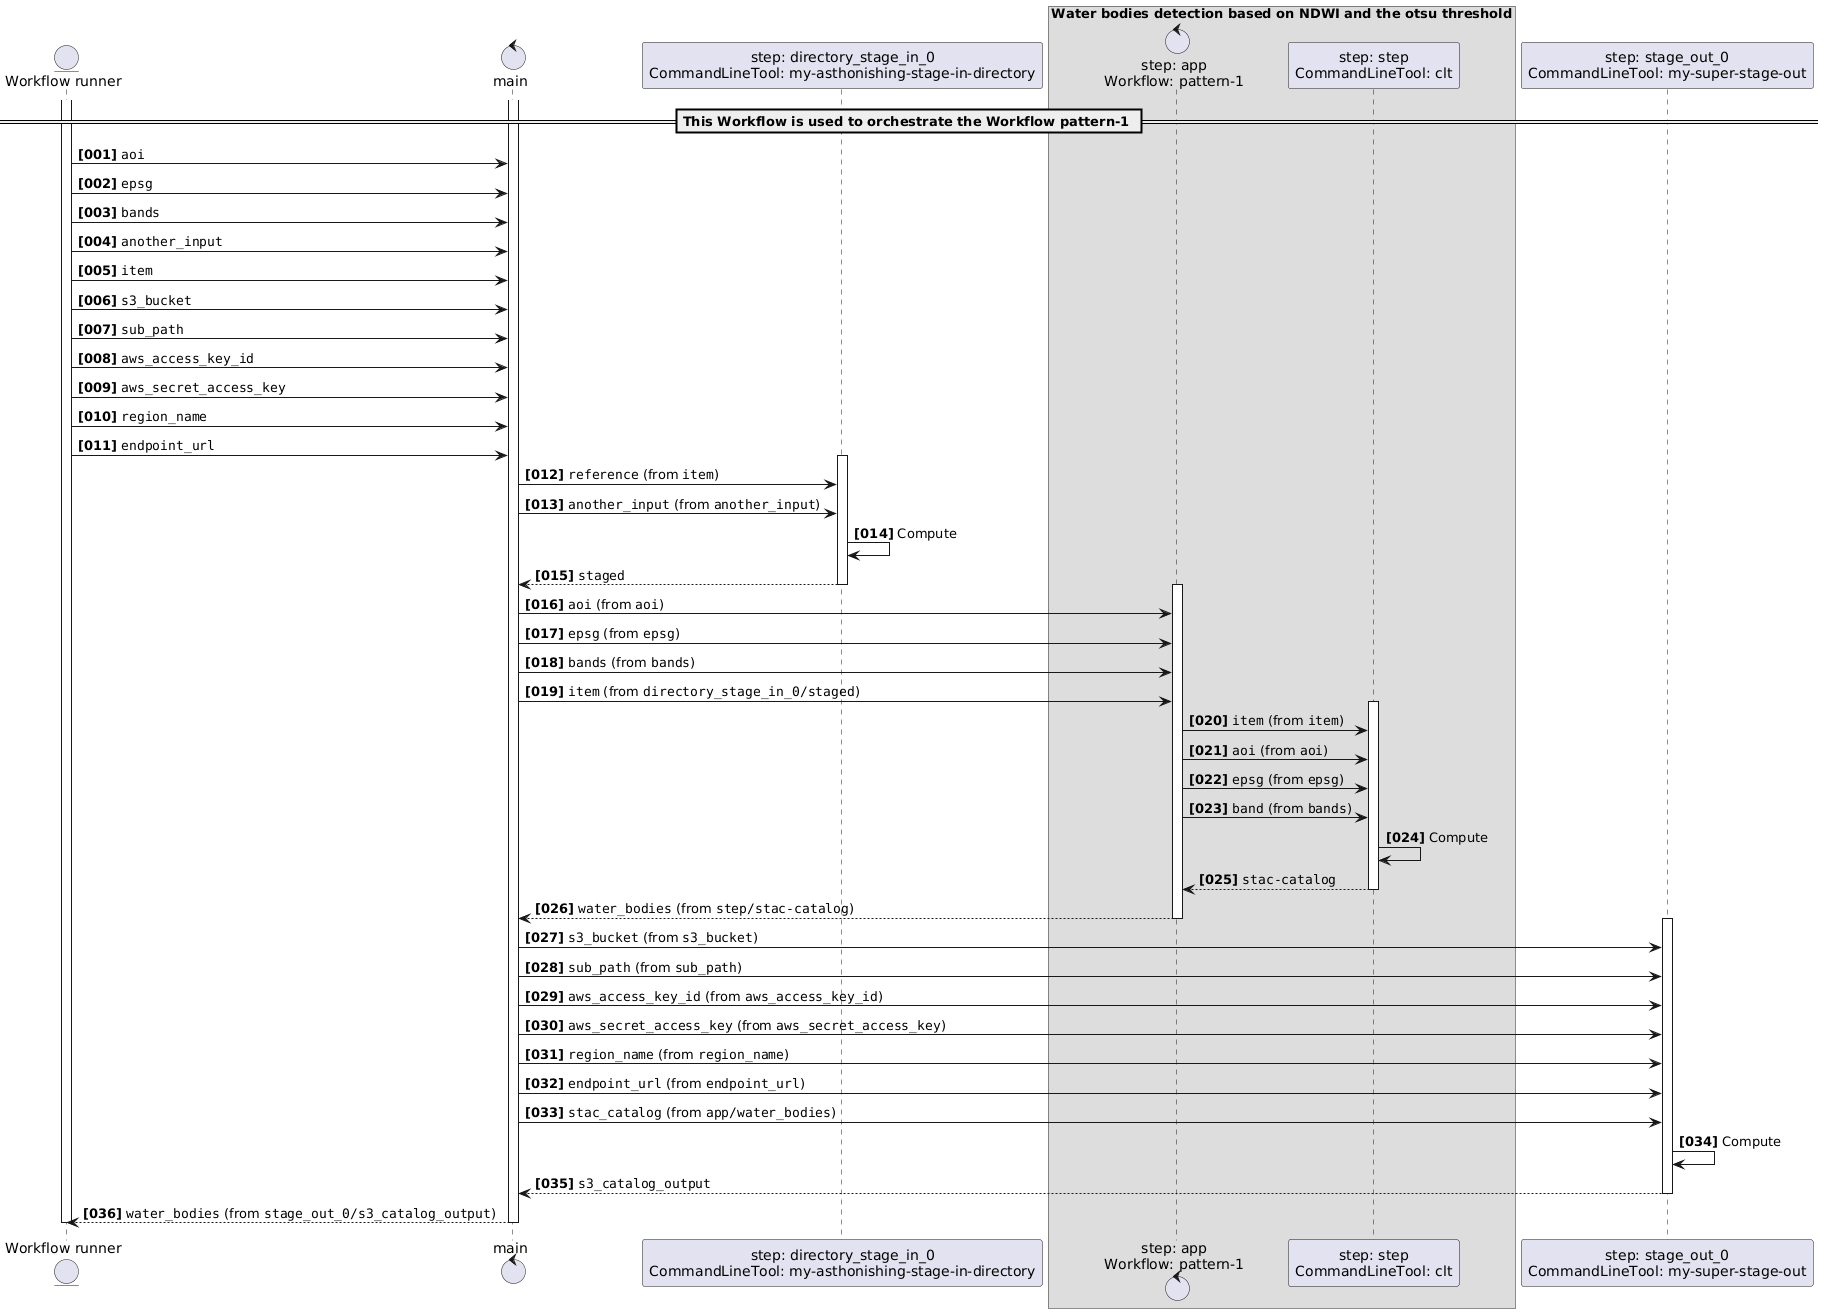

In [13]:
wf.display_sequence_diagram()

### Inputs

In [14]:
wf.display_inputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `aoi` | `string` | area of interest - pattern-1/aoi | area of interest as a bounding box - This parameter is derived from pattern-1/aoi |
| `epsg` | `string` | EPSG code - pattern-1/epsg | EPSG code - This parameter is derived from pattern-1/epsg |
| `bands` | `string[]` | bands used for the NDWI - pattern-1/bands | bands used for the NDWI - This parameter is derived from pattern-1/bands |
| `another_input` | `string` | Another Input - my-asthonishing-stage-in-directory/another_input | An additional input for demonstration purposes - This parameter is derived from my-asthonishing-stage-in-directory/another_input |
| `item` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Landsat-8/9 acquisition reference - pattern-1/item | Landsat-8/9 acquisition reference - This parameter is derived from pattern-1/item |
| `s3_bucket` | `string` | my-super-stage-out/s3_bucket | This parameter is derived from: my-super-stage-out/s3_bucket |
| `sub_path` | `string` | my-super-stage-out/sub_path | This parameter is derived from: my-super-stage-out/sub_path |
| `aws_access_key_id` | `string` | my-super-stage-out/aws_access_key_id | This parameter is derived from: my-super-stage-out/aws_access_key_id |
| `aws_secret_access_key` | `string` | my-super-stage-out/aws_secret_access_key | This parameter is derived from: my-super-stage-out/aws_secret_access_key |
| `region_name` | `string` | my-super-stage-out/region_name | This parameter is derived from: my-super-stage-out/region_name |
| `endpoint_url` | `string` | my-super-stage-out/endpoint_url | This parameter is derived from: my-super-stage-out/endpoint_url |


### Steps

In [15]:
wf.display_steps()

| Id | Runs | Label | Doc |
| --- | --- | --- | --- |
| `directory_stage_in_0` | `#my-asthonishing-stage-in-directory` | None | None |
| `app` | `#pattern-1` | None | None |
| `stage_out_0` | `#my-super-stage-out` | None | None |


### Outputs

In [16]:
wf.display_outputs()

| Id | Type | Label | Doc |
| --- | --- | --- | --- |
| `water_bodies` | `https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI` | Water bodies detected | Water bodies detected based on the NDWI and otsu threshold |


## Execution


In [17]:
from cwltool.main import main
from io import StringIO
import argparse
import yaml

In [18]:
with open(".params.yaml", "w") as f:
    yaml.dump({**app_inputs, **additional_inputs}, f)

md = f"""

### Inputs

```json
{json.dumps({**app_inputs, **additional_inputs}, indent=2)}
```
"""

display(Markdown(md))



### Inputs

```json
{
  "aoi": "-118.985,38.432,-118.183,38.938",
  "epsg": "EPSG:4326",
  "bands": [
    "green",
    "nir08"
  ],
  "item": {
    "class": "https://raw.githubusercontent.com/eoap/schemas/main/url.yaml#URL",
    "value": "https://planetarycomputer.microsoft.com/api/stac/v1/collections/landsat-c2-l2/items/LC08_L2SP_042033_20231007_02_T1"
  },
  "another_input": "some_value",
  "s3_bucket": "my-bucket",
  "sub_path": "my/sub/path",
  "aws_access_key_id": "test",
  "aws_secret_access_key": "test",
  "region_name": "us-west-1",
  "endpoint_url": "https://s3.us-west-1.amazonaws.com"
}
```


In [19]:
parsed_args = argparse.Namespace(
    podman=False,
    debug=False,
    validate=False,
    outdir="./runs",
    workflow=f"{app_cwl_file}#main",
    job_order=[".params.yaml"],
)

stream_out = StringIO()
stream_err = StringIO()

res = main(
    args=parsed_args,
    stdout=stream_out,
    stderr=stream_err,
)

if res == 0:
    md = f"""

### Outputs

```json
{stream_out.getvalue()}
```
    """
else:
    md = f"""

### Errors

CWL execution terminated with errors:

```
{stream_err.getvalue()}
```
    """

display(Markdown(md))



### Outputs

```json
{
    "water_bodies": {
        "value": "s3://my-bucket/my/sub/path-1b9e57/catalog.json",
        "type": "https://raw.githubusercontent.com/eoap/schemas/main/string_format.yaml#URI"
    }
}
```
    